# Naive Bayes Mejorado - Clasificación de Precio

In [1]:
import pyreadr
import pandas as pd
import numpy as np

In [2]:
result = pyreadr.read_r('data/listings.RData')
df = result['listings']
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,city
0,5456.0,https://www.airbnb.com/rooms/5456,2.025092e+13,2025-09-17,city scrape,"Walk to 6th, Rainey St and Convention Ctr",Great central location for walking to Convent...,My neighborhood is ideally located if you want...,https://a0.muscache.com/pictures/14084884/b5a3...,8028,...,4.73,4.79,NaN,f,1,1,0,0,3.52,"Austin, Texas"
1,6448.0,https://www.airbnb.com/rooms/6448,2.025092e+13,2025-09-17,city scrape,"Secluded Studio @ Zilker - King Bed, Bright & ...","Clean, private space with everything you need ...",The neighborhood is fun and funky (but quiet)!...,https://a0.muscache.com/pictures/airflow/Hosti...,14156,...,4.97,4.88,NaN,t,1,1,0,0,1.98,"Austin, Texas"
2,8502.0,https://www.airbnb.com/rooms/8502,2.025092e+13,2025-09-17,city scrape,Woodland Studio Lodging,Studio rental on lower level of home located i...,,https://a0.muscache.com/pictures/miso/Hosting-...,25298,...,4.69,4.63,NaN,f,1,1,0,0,0.28,"Austin, Texas"
3,13035.0,https://www.airbnb.com/rooms/13035,2.025092e+13,2025-09-17,city scrape,Historic house in highly walkable East Austin,Comfortable 2 bedroom/2 bathroom home very cen...,East Cesar Chavez is a gentrifying urban area ...,https://a0.muscache.com/pictures/miso/Hosting-...,50793,...,5.00,4.95,NaN,f,2,2,0,0,0.11,"Austin, Texas"
4,22828.0,https://www.airbnb.com/rooms/22828,2.025092e+13,2025-09-16,city scrape,Garage Apartment central SE Austin,"Fully furnished, centrally located, second sto...","wikipedia: East_Riverside-Oltorf,_Austin,_Texas",https://a0.muscache.com/pictures/miso/Hosting-...,56488,...,4.72,4.84,NaN,f,1,1,0,0,0.30,"Austin, Texas"


## Limpieza de precio

In [3]:
df['price'] = pd.to_numeric(
    df['price'].replace(r'[\$,]', '', regex=True),
    errors='coerce'
)

## Eliminar outliers

In [4]:
df = df[df['price'] < df['price'].quantile(0.99)]

## Crear categorías

In [5]:
df['price_category'] = pd.qcut(df['price'], q=3, labels=['barata','media','cara'])

C:\Users\ninan\AppData\Local\Temp\ipykernel_12064\2008432881.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['price_category'] = pd.qcut(df['price'], q=3, labels=['barata','media','cara'])


## Selección de variables 

In [6]:
features = [
    'accommodates',
    'bathrooms',
    'bedrooms',
    'beds',
    'review_scores_rating',
    'number_of_reviews',
    'availability_365'
]

df_model = df[features + ['price_category']].dropna()

## Split

In [7]:
from sklearn.model_selection import train_test_split

X = df_model[features]
y = df_model['price_category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Escalado

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Modelo

In [9]:
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()
model.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


## Predicciones

In [10]:
y_pred = model.predict(X_test)

## Evaluación

In [11]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred)

print(cm)
print(classification_report(y_test, y_pred))

[[3608  197  613]
 [ 717 1868 1283]
 [2220  571 1434]]
              precision    recall  f1-score   support

      barata       0.55      0.82      0.66      4418
        cara       0.71      0.48      0.57      3868
       media       0.43      0.34      0.38      4225

    accuracy                           0.55     12511
   macro avg       0.56      0.55      0.54     12511
weighted avg       0.56      0.55      0.54     12511



## Visualización

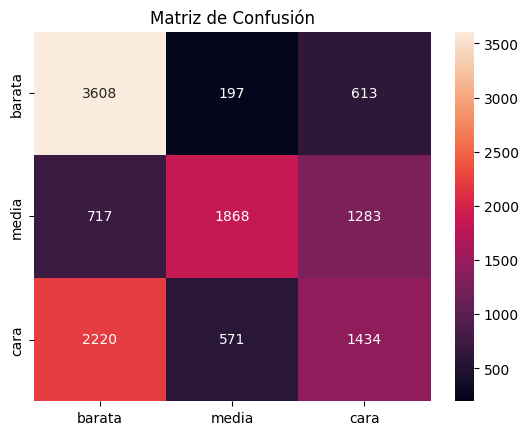

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['barata','media','cara'],
            yticklabels=['barata','media','cara'])

plt.title('Matriz de Confusión')
plt.show()

## Tuneo de hiperparámetros del modelo de clasificación

Mejor hiperparámetro: {'var_smoothing': 1e-12}
Mejor accuracy promedio en validación cruzada: 0.5527


,Modelo,Accuracy,F1 weighted
0,Base,0.552314,0.538223
1,Tuneado,0.552314,0.538223



Reporte del modelo tuneado:
              precision    recall  f1-score   support

      barata       0.55      0.82      0.66      4418
        cara       0.71      0.48      0.57      3868
       media       0.43      0.34      0.38      4225

    accuracy                           0.55     12511
   macro avg       0.56      0.55      0.54     12511
weighted avg       0.56      0.55      0.54     12511

Matriz de confusión tuneada:
[[3608  197  613]
 [ 717 1868 1283]
 [2220  571 1434]]


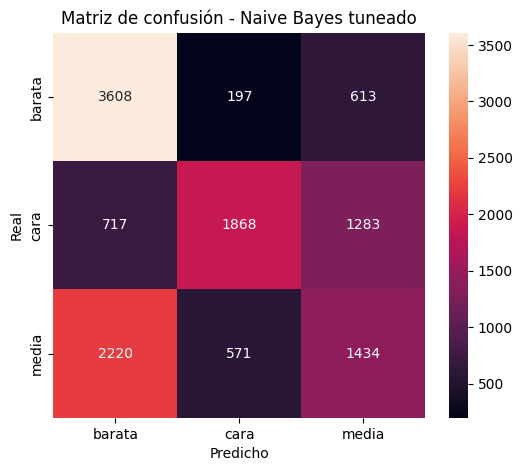

,param_var_smoothing,mean_test_score,std_test_score,rank_test_score
0,1.000000e-12,0.552676,0.003143,1
1,1.000000e-11,0.552676,0.003143,1
2,1.000000e-10,0.552676,0.003143,1
3,1.000000e-09,0.552676,0.003143,1
4,1.000000e-08,0.552676,0.003143,1
5,1.000000e-07,0.552676,0.003143,1
6,1.000000e-06,0.552676,0.003143,1
7,1.000000e-05,0.552676,0.003143,1
8,1.000000e-04,0.552676,0.003143,1
9,1.000000e-03,0.552596,0.003049,10


In [13]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.naive_bayes import GaussianNB
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Predicciones del modelo base
y_pred_base = model.predict(X_test)

base_acc = accuracy_score(y_test, y_pred_base)
base_f1 = f1_score(y_test, y_pred_base, average='weighted')

# Hiperparámetro 
param_grid = {
    "var_smoothing": np.logspace(-12, -3, 10)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_nb = GridSearchCV(
    estimator=GaussianNB(),
    param_grid=param_grid,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1
)

grid_nb.fit(X_train, y_train)

best_model_cls = grid_nb.best_estimator_
y_pred_tuned = best_model_cls.predict(X_test)

tuned_acc = accuracy_score(y_test, y_pred_tuned)
tuned_f1 = f1_score(y_test, y_pred_tuned, average='weighted')

comparacion_cls = pd.DataFrame({
    "Modelo": ["Base", "Tuneado"],
    "Accuracy": [base_acc, tuned_acc],
    "F1 weighted": [base_f1, tuned_f1]
})

print("Mejor hiperparámetro:", grid_nb.best_params_)
print("Mejor accuracy promedio en validación cruzada:", round(grid_nb.best_score_, 4))
display(comparacion_cls)

print("\nReporte del modelo tuneado:")
print(classification_report(y_test, y_pred_tuned))

cm_tuned = confusion_matrix(y_test, y_pred_tuned)
print("Matriz de confusión tuneada:")
print(cm_tuned)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_tuned,
    annot=True,
    fmt='d',
    xticklabels=best_model_cls.classes_,
    yticklabels=best_model_cls.classes_
)
plt.title("Matriz de confusión - Naive Bayes tuneado")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.show()

resultados_grid_cls = pd.DataFrame(grid_nb.cv_results_)[
    ["param_var_smoothing", "mean_test_score", "std_test_score", "rank_test_score"]
].sort_values("rank_test_score")

display(resultados_grid_cls.head(10))